# 선형회귀 모델 작성, 예측, 평가

In [25]:
# LinearRegressor & RandomForestRegressor()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
import seaborn as sns

In [27]:
premiumDF = pd.read_csv('./data/premium.csv')

In [28]:
premiumDF.info()
# bmi에 결측치 존재

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1333 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


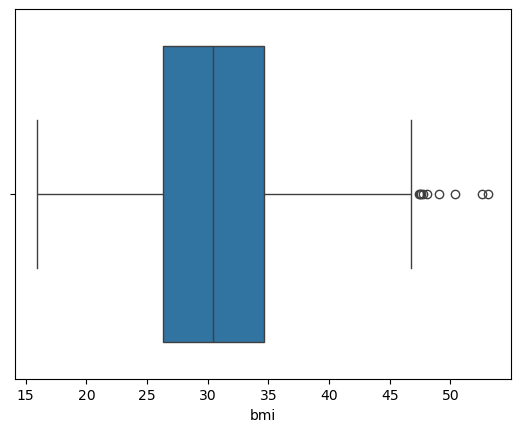

In [29]:
sns.boxplot(data=premiumDF, x='bmi')
plt.show()

In [30]:
# bmi 결측치 평균값으로 대체
premiumDF['bmi'].fillna(premiumDF['bmi'].mean(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11276\3280181247.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  premiumDF['bmi'].fillna(premiumDF['bmi'].mean(), inplace=True)


In [31]:
# sex: female → 0, male → 1
# smoker: no → 0, yes → 1
premiumDF['sex'] = premiumDF['sex'].map({'female': 0, 'male': 1})
premiumDF['smoker'] = premiumDF['smoker'].map({'no': 0, 'yes': 1})

In [32]:
# region — 다중 범주형 컬럼 → 원-핫 인코딩
premiumDF = pd.get_dummies(premiumDF, columns=['region'], drop_first=True)

In [33]:
premiumDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [34]:
from sklearn.preprocessing import MinMaxScaler
scaler =  MinMaxScaler()
df_scaled = scaler.fit_transform(premiumDF)

In [35]:
X = premiumDF.drop('charges', axis=1)
y = premiumDF['charges']

In [36]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1338 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1338 non-null   float64
dtypes: float64(1)
memory usage: 10.6 KB


In [37]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Random Forest 기본 모델 학습 및 예측
rf = RandomForestRegressor(random_state=42)  # 기본 하이퍼파라미터 사용
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

def evaluate(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} 모델 성능:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2: {r2:.3f}\n")


evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

Linear Regression 모델 성능:
  RMSE: 5798.88
  R2: 0.783

Random Forest 모델 성능:
  RMSE: 4633.02
  R2: 0.862



In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

# 모델 생성
rf = RandomForestRegressor(random_state=42)
lr = LinearRegression()

def cross_val_evaluate(model, X, y):
    neg_mse_scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)

    r2_scores = cross_val_score(
        model, X, y,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )

    print(f"{model.__class__.__name__} 교차검증 결과:")

    print("  평균 RMSE:", rmse_scores.mean())
    print("  R2 점수:", np.round(r2_scores, 3))
    print("  평균 R2:", r2_scores.mean())
    print()

# 평가 실행
cross_val_evaluate(lr, X, y)
cross_val_evaluate(rf, X, y)


LinearRegression 교차검증 결과:
  평균 RMSE: 6085.754599270111
  R2 점수: [0.76  0.705 0.775 0.733 0.756]
  평균 R2: 0.745781545550763

RandomForestRegressor 교차검증 결과:
  평균 RMSE: 4947.670806459477
  R2 점수: [0.854 0.772 0.851 0.828 0.849]
  평균 R2: 0.8306263502294163



In [39]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   region_northwest  1338 non-null   bool   
 6   region_southeast  1338 non-null   bool   
 7   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(1), int64(4)
memory usage: 56.3 KB


In [40]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 불리언 컬럼 int로 변환 (X가 아직 bool이면)
X = X.astype({col: 'int' for col in X.select_dtypes('bool').columns})

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

# 1. 다항 회귀 (degree=2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE 계산
r2 = r2_score(y_test, y_pred)
results.append(["다항회귀", mse, rmse, r2])

# 2. 릿지 회귀
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
results.append(["릿지회귀", mse, rmse, r2])

# 3. 라쏘 회귀
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1))
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
results.append(["라쏘회귀", mse, rmse, r2])

# 4. 엘라스틱넷 회귀
elastic = make_pipeline(StandardScaler(), ElasticNet(alpha=0.1, l1_ratio=0.5))
elastic.fit(X_train, y_train)
y_pred = elastic.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
results.append(["엘라스틱넷회귀", mse, rmse, r2])

# 결과 출력
df_results = pd.DataFrame(results, columns=["모델", "MSE", "RMSE", "R2"])
print(df_results)


        모델           MSE         RMSE        R2
0     다항회귀  2.105533e+07  4588.608999  0.864377
1     릿지회귀  3.363507e+07  5799.574934  0.783347
2     라쏘회귀  3.362746e+07  5798.919038  0.783396
3  엘라스틱넷회귀  3.429758e+07  5856.413959  0.779080
